# **2. Alter × Jahr Interaktion**

## **Ziel**

Untersuchen, ob sich das leistungsrelevante Alter *über die Zeit verschiebt*.

In [13]:
from pathlib import Path
import sys
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import plotting.plotting_style as plt
import util
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
df = util.load_data("../../data_csv/final_Data_iaaf_scores_neu.csv", youth=True)
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146
...,...,...,...,...,...,...,...,...,...,...,...,...
226678,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck,545
226679,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale),543
226680,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg),542
226681,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde,541


### **1. Datenaufbereitung**

- Alter in ganzzahlige Bins (z. B. 1-Jahres-Bins)
- Pro (Jahr, Alter, Geschlecht):
    - Mindest-N (z. B. ≥ 5 Leistungen)

In [15]:
df_d = df[df['disziplin'] == '100 m'].copy()

df_d["alter"] = df_d["jahr"] - df_d["geburtsjahr"]

print(df_d[df_d['alter'] < 15])

min_n = 5
grouped_counts = df_d.groupby(['jahr', 'alter', 'geschlecht']).size().reset_index(name='n')

valid_groups = grouped_counts[grouped_counts['n'] >= min_n]
df_valid = df_d.merge(valid_groups[['jahr', 'alter', 'geschlecht']], on=['jahr', 'alter',  'geschlecht'], how='inner')

df_valid

        jahr geschlecht altersklasse disziplin  leistung  wind  \
3514    2006          W           20     100 m     12.00   NaN   
5697    2004          W           16     100 m     12.19   NaN   
5707    2004          W           16     100 m     12.38   NaN   
5708    2004          W           16     100 m     12.40   NaN   
5712    2004          W           16     100 m     12.44   NaN   
...      ...        ...          ...       ...       ...   ...   
226170  2023          M           14     100 m     12.06   1.0   
226171  2023          M           14     100 m     12.06  -1.1   
226172  2023          M           14     100 m     12.07   0.9   
226173  2023          M           14     100 m     12.07  -0.1   
226174  2023          M           14     100 m     12.07   1.4   

                           name  geburtsjahr                        verein  \
3514             Saskia Schmitz         1992  LAV Bayer Uerdingen/Dormagen   
5697                  Lisa Wolf         1990       

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,alter
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,21
1,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,21
2,2017,W,Frauen,100 m,11.29,1.9,Jennifer Montag,1998,TSV Bayer 04 Leverkusen,11.06.,Regensburg,1137,19
3,2017,W,Frauen,100 m,11.33,1.7,Keshia Kwadwo,1999,TV Wattenscheid 01,04.08.,Ulm,1129,18
4,2017,W,Frauen,100 m,11.41,1.8,Lisa Nippgen,1997,LAZ Ludwigsburg,01.07.,Mannheim,1112,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10560,2023,M,14,100 m,12.06,1.0,Bruno Horst,2009,LV Schinne 2013,26.08.2023,Bernburg,601,14
10561,2023,M,14,100 m,12.06,-1.1,Quentin Breidbach,2009,ASV Koeln,09.09.2023,Neuss,601,14
10562,2023,M,14,100 m,12.07,0.9,Nathan Timothy Knobloch,2009,Eintracht Frankfurt,03.06.2023,Bad Homburg vor der Hoehe,598,14
10563,2023,M,14,100 m,12.07,-0.1,Julian Kanitz,2009,Aachener TG,10.06.2023,Duisburg,598,14


### **2. Leistungsaggregation**

- Berechne:
    - Median-Leistung
    - Optional: 10 %-Quantil (Top-Leistung)

In [16]:
agg = df_valid.groupby(['jahr', 'alter', 'geschlecht']).agg(
    median_iaaf_score=('iaaf_score', 'median'),
    top10=('iaaf_score', lambda x: np.percentile(x, 10))
).reset_index()

agg

,jahr,alter,geschlecht,median_iaaf_score,top10
0,2001,14,M,660.0,631.7
1,2001,14,W,882.0,841.4
2,2001,15,M,748.5,716.5
3,2001,15,W,931.0,895.4
4,2001,16,M,874.0,822.0
...,...,...,...,...,...
468,2024,23,M,1047.0,1021.8
469,2024,23,W,1098.5,1066.0
470,2024,24,M,1117.5,1015.0
471,2024,27,M,1047.0,1018.6


### **3. Visualisierung**

- Heatmap:
    - x-Achse: Jahr
    - y-Achse: Alter
    - Farbe: aggregierte Leistung
- Separate Plots pro Geschlecht

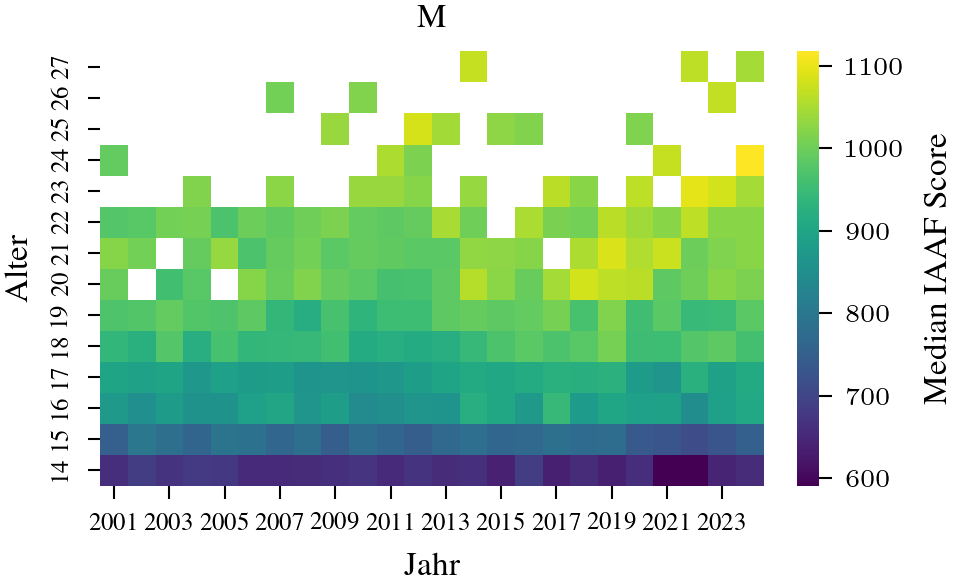

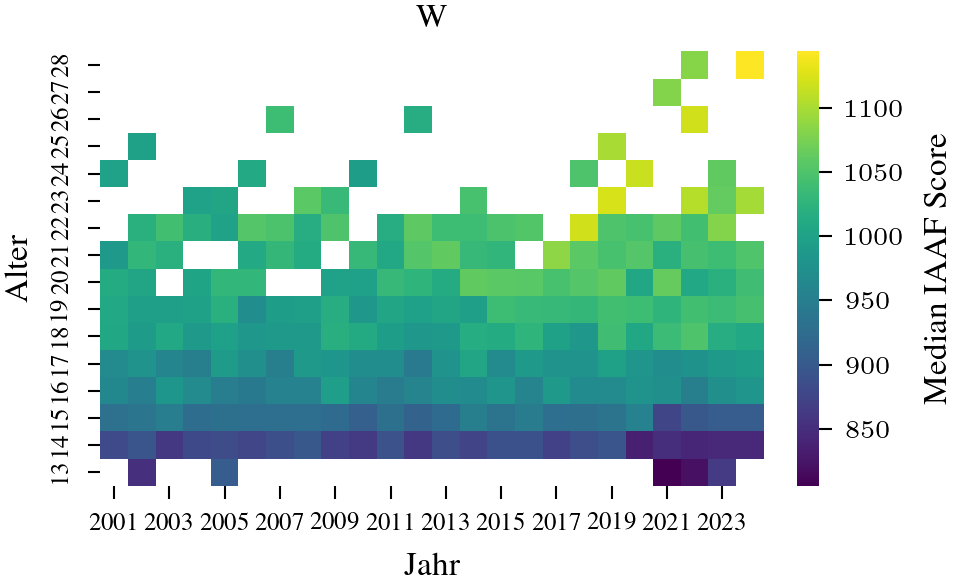

In [17]:
geschlechter = agg['geschlecht'].unique()

for g in geschlechter:
    data = agg[agg['geschlecht'] == g].pivot(index='alter', columns='jahr', values='median_iaaf_score')

    sns.heatmap(data, cmap='viridis', cbar_kws={'label': 'Median IAAF Score'})
    # im = plt.imshow(data, aspect="auto")
    # plt.colorbar(im, fraction=0.046, label='Median IAAF Score')

    plt.title(g)
    plt.xlabel('Jahr')
    plt.ylabel('Alter')
    plt.gca().invert_yaxis()
    plt.show()

### **4. Drift-Quantifizierung**

- Pro Jahr:
    - Alter des minimalen Medians bestimmen
- Trendanalyse:
    - lineare Regression: PeakAlter ~ Jahr

Optimales Alter verschiebt sich um 0.47 Jahre pro Dekade


/var/folders/lf/d2nc392142b837mf8sypzlx00000gn/T/ipykernel_44025/1348229804.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peak_ages = agg.groupby(['jahr', 'geschlecht']).apply(


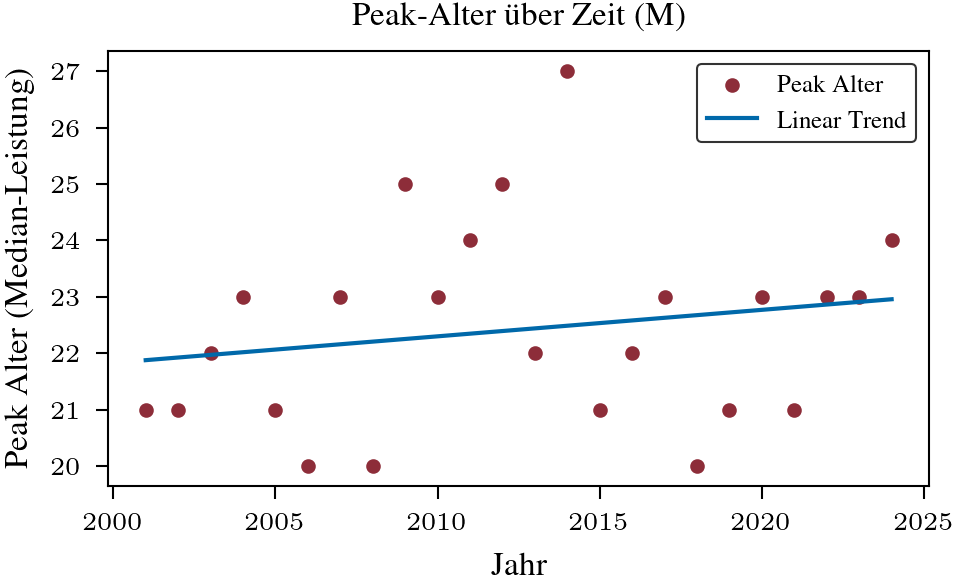

Optimales Alter verschiebt sich um 1.74 Jahre pro Dekade


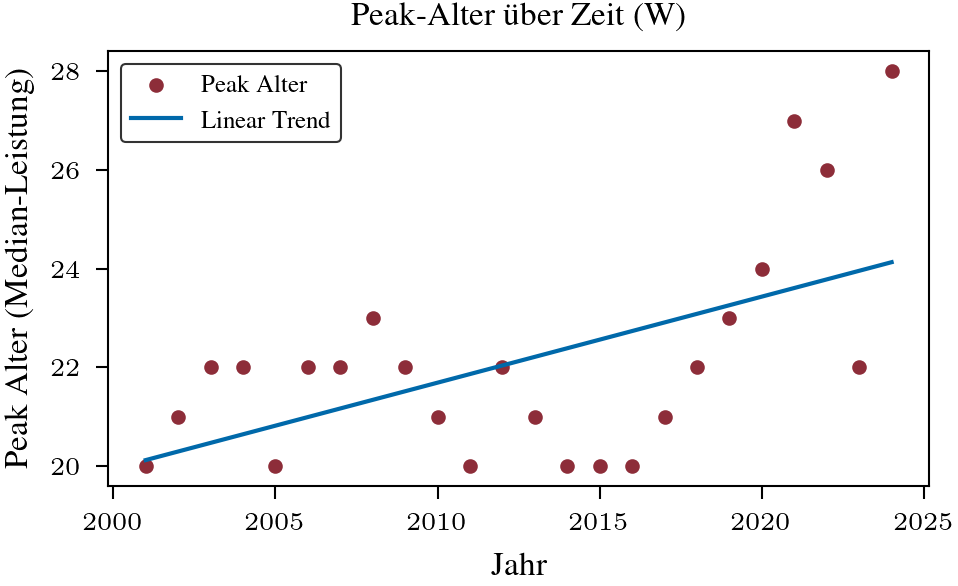

In [18]:
from sklearn.linear_model import LinearRegression

peak_ages = agg.groupby(['jahr', 'geschlecht']).apply(
    lambda x: x.loc[x['median_iaaf_score'].idxmax(), 'alter']
).reset_index(name='peak_alter')

for g in peak_ages['geschlecht'].unique():
    # Beispiel für ein Geschlecht
    # g = 'W'
    data_g = peak_ages[peak_ages['geschlecht'] == g]

    X = data_g['jahr'].values.reshape(-1, 1)
    y = data_g['peak_alter'].values

    model = LinearRegression()
    model.fit(X, y)

    trend_slope = model.coef_[0]  # Jahre pro Einheit Anstieg/Abnahme
    print(f"Optimales Alter verschiebt sich um {trend_slope*10:.2f} Jahre pro Dekade")

    # Plot Peak-Alter über die Zeit
    # plt.figure(figsize=(10,6))
    plt.scatter(X, y, label='Peak Alter', marker='.')
    plt.plot(X, model.predict(X), color=plt.rgb.tue_blue, label='Linear Trend')
    plt.xlabel('Jahr')
    plt.ylabel('Peak Alter (Median-Leistung)')
    plt.title(f'Peak-Alter über Zeit ({g})')
    plt.legend()
    plt.show()